# **DEMO PROJECT ( 1 DATABASE )**

In [ ]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 102.6 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import wfdb
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
record = wfdb.rdrecord('100', pn_dir='mitdb')
signal = record.p_signal[:,0]

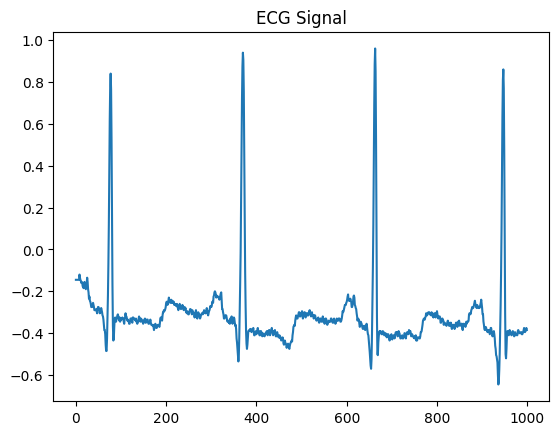

In [ ]:
plt.plot(signal[:1000])
plt.title("ECG Signal")
plt.show()

In [ ]:
def bandpass_filter(data):
    b, a = butter(3, [0.5, 40], btype='bandpass', fs=360)
    return filtfilt(b, a, data)

filtered = bandpass_filter(signal)

In [ ]:
peaks, _ = find_peaks(filtered, distance=150)

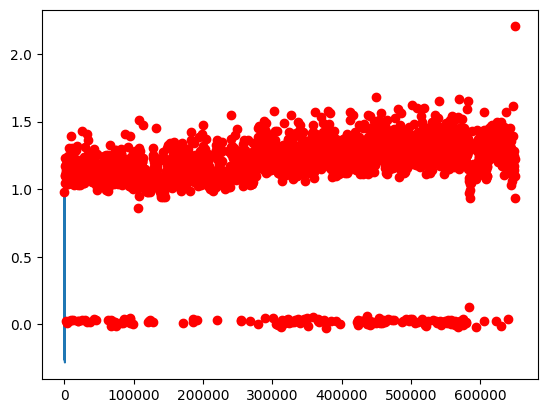

In [ ]:
plt.plot(filtered[:1000])
plt.plot(peaks, filtered[peaks], "ro")
plt.show()

In [ ]:
rr_intervals = np.diff(peaks)

features = [
    np.mean(rr_intervals),
    np.std(rr_intervals),
    np.max(filtered),
    np.min(filtered)
]

X = [features, features]
y = [0, 1]

In [ ]:
model = SVC()
model.fit(X, y)

SVC()

# ECG SIGNAL PROCESSING AND ARRHYTHMIA DETECTION USING MACHINE LEARNING

In [ ]:
!pip install wfdb numpy scipy scikit-learn matplotlib seaborn

Data Load (Multiple Records + Annotations)

In [ ]:
import wfdb
import numpy as np

records = ['100','101','102','103','104','105']  # 5–10 records enough

all_segments = []
all_labels = []

Preprocessing (Filter)

In [ ]:
from scipy.signal import butter, filtfilt

def bandpass_filter(sig, fs=360):
    b, a = butter(3, [0.5, 40], btype='bandpass', fs=fs)
    return filtfilt(b, a, sig)

Beat Segmentation

In [ ]:
from scipy.signal import find_peaks

for rec in records:
    record = wfdb.rdrecord(rec, pn_dir='mitdb')
    annotation = wfdb.rdann(rec, 'atr', pn_dir='mitdb')

    signal = record.p_signal[:,0]
    signal = bandpass_filter(signal)

    peaks = annotation.sample      # R-peaks (BEST way)
    symbols = annotation.symbol    # labels

    for i in range(1, len(peaks)-1):
        peak = peaks[i]

        # window around peak
        segment = signal[peak-100:peak+100]

        if len(segment) == 200:
            all_segments.append(segment)

            # Labeling (simplified)
            if symbols[i] == 'N':
                all_labels.append(0)   # Normal
            else:
                all_labels.append(1)   # Abnormal

Feature Extraction

In [ ]:
def extract_features(segment):
    return [
        np.mean(segment),
        np.std(segment),
        np.max(segment),
        np.min(segment)
    ]

X = [extract_features(seg) for seg in all_segments]
y = all_labels

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train Models

SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC()
svm_model.fit(X_train, y_train)

SVC()

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

Prediction

In [ ]:
y_pred_svm = svm_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

SVM Accuracy: 0.9433681073025335
RF Accuracy: 0.9683308494783904
Confusion Matrix:
 [[1803   17]
 [  68  796]]


Visualization

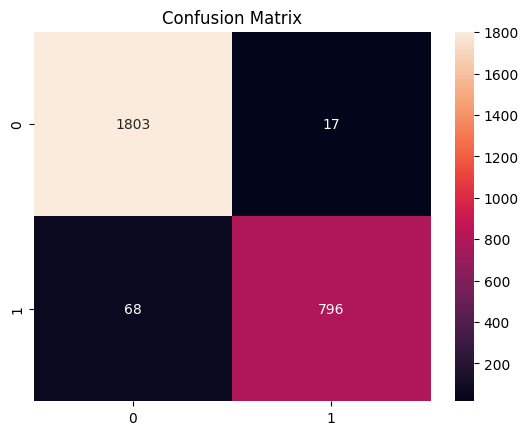

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

# ECG SIGNAL PROCESSING AND ARRHYTHMIA DETECTION USING MACHINE LEARNING

INSTALL

In [ ]:
!pip install wfdb

Import Libraries

In [ ]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

Bandpass Filter

In [ ]:
def bandpass_filter(sig, fs=360):
    b, a = butter(3, [0.5, 40], btype='bandpass', fs=fs)
    return filtfilt(b, a, sig)

Show Raw ECG

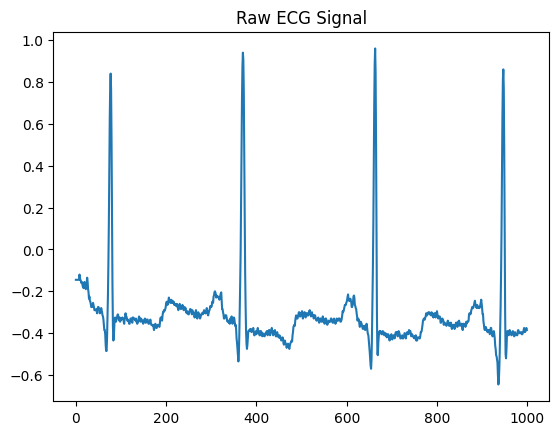

In [ ]:
record = wfdb.rdrecord('100', pn_dir='mitdb')
signal = record.p_signal[:,0]
plt.plot(signal[:1000])
plt.title("Raw ECG Signal")
plt.show()

Filtered ECG

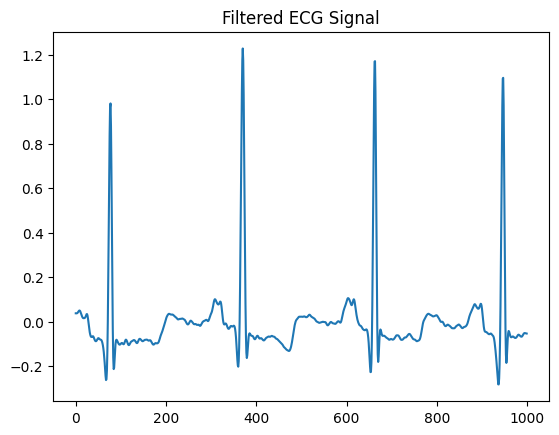

In [ ]:
filtered = bandpass_filter(signal)
plt.plot(filtered[:1000])
plt.title("Filtered ECG Signal")
plt.show()

R - Peak Detection

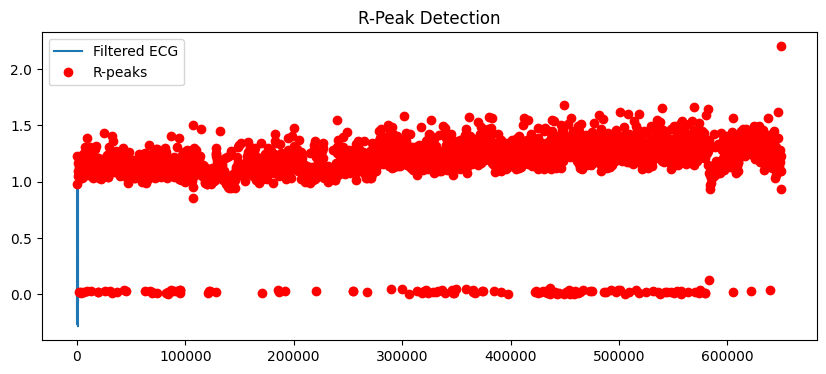

In [ ]:
from scipy.signal import find_peaks
peaks, _ = find_peaks(filtered, distance=150, height=np.mean(filtered))
plt.figure(figsize=(10,4))
plt.plot(filtered[:1000], label="Filtered ECG")
plt.plot(peaks, filtered[peaks], "ro", label="R-peaks")
plt.title("R-Peak Detection")
plt.legend()
plt.show()

Heart rate calculation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 68.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
Average Heart Rate: 80.2629270949695 bpm


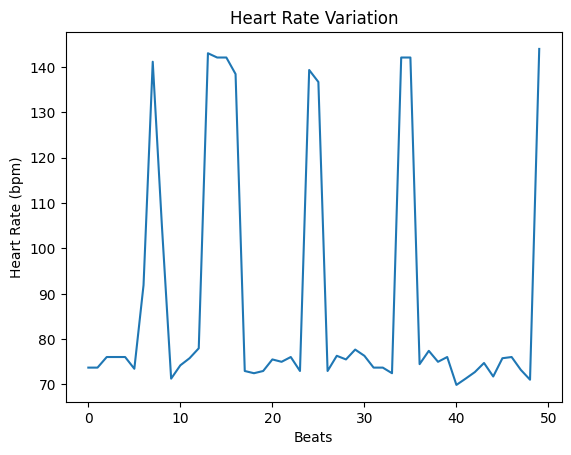

In [ ]:
!pip install wfdb
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
def bandpass_filter(sig, fs=360):
    b, a = butter(3, [0.5, 40], btype='bandpass', fs=fs)
    return filtfilt(b, a, sig)
record = wfdb.rdrecord('100', pn_dir='mitdb')
signal = record.p_signal[:,0]
filtered = bandpass_filter(signal)
peaks, _ = find_peaks(filtered, distance=150)
rr_intervals = np.diff(peaks) / 360
heart_rate = 60 / np.mean(rr_intervals)
print("Average Heart Rate:", heart_rate, "bpm")
hr_each = 60 / rr_intervals
plt.plot(hr_each[:50])
plt.title("Heart Rate Variation")
plt.xlabel("Beats")
plt.ylabel("Heart Rate (bpm)")
plt.show()


Load Data + Segmentation

In [ ]:
records = ['100','101','102','103','104','105']
all_segments = []
all_labels = []
for rec in records:
    record = wfdb.rdrecord(rec, pn_dir='mitdb')
    annotation = wfdb.rdann(rec, 'atr', pn_dir='mitdb')
    signal = record.p_signal[:,0]
    signal = bandpass_filter(signal)
    peaks = annotation.sample
    symbols = annotation.symbol
    for i in range(1, len(peaks)-1):
        peak = peaks[i]
        if peak-100 >= 0 and peak+100 < len(signal):
            segment = signal[peak-100:peak+100]
            if len(segment) == 200:
                all_segments.append(segment)
                if symbols[i] == 'N':
                    all_labels.append(0)
                else:
                    all_labels.append(1)

Check Data

In [ ]:
print("Total Segments:", len(all_segments))
print("Total Labels:", len(all_labels))

Total Segments: 13418
Total Labels: 13418


Feature Extraction

In [ ]:
def extract_features(segment):
    return [
        np.mean(segment),
        np.std(segment),
        np.max(segment),
        np.min(segment),
        np.median(segment),
        np.ptp(segment)
    ]
X = [extract_features(seg) for seg in all_segments]
y = all_labels
print("Sample Feature:", X[0])

Sample Feature: [np.float64(0.00908912581799442), np.float64(0.2189319519317806), np.float64(1.227471158947131), np.float64(-0.20248250391944458), np.float64(-0.05348211126742679), np.float64(1.4299536628665757)]


Feature Scaling

In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 10734
Test size: 2684


Train Models

SVM

In [ ]:
svm_model = SVC()
svm_model.fit(X_train, y_train)

SVC()

Random Forest

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

RandomForestClassifier()

Prediction

In [ ]:
y_pred_svm = svm_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

Accuracy

In [ ]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

SVM Accuracy: 0.9631147540983607
RF Accuracy: 0.9713114754098361
Confusion Matrix:
 [[1810   10]
 [  67  797]]


Confusion Matrix

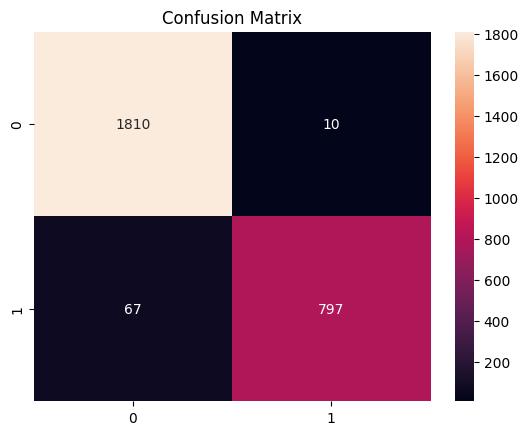

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Classification Report

In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1820
           1       0.99      0.92      0.95       864

    accuracy                           0.97      2684
   macro avg       0.98      0.96      0.97      2684
weighted avg       0.97      0.97      0.97      2684



Accuracy Comparison Graph

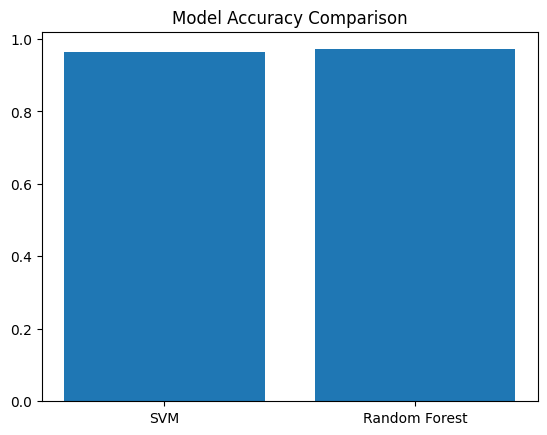

In [ ]:
models = ['SVM', 'Random Forest']
acc = [
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rf)
]
plt.bar(models, acc)
plt.title("Model Accuracy Comparison")
plt.show()

Class Distribution

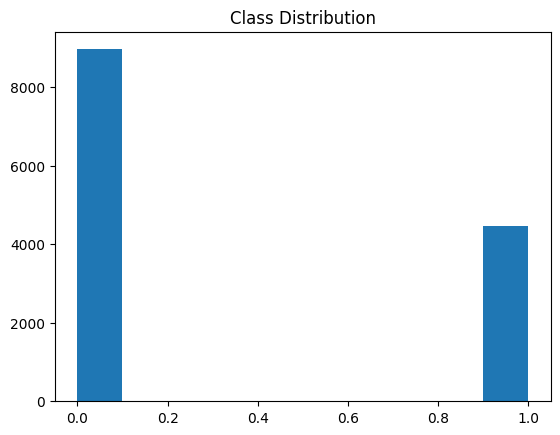

In [ ]:
plt.hist(y)
plt.title("Class Distribution")
plt.show()